In [2]:
import pandas as pd

df = pd.read_csv(
    r"C:/Users/Nikhil/OneDrive/Documents/Python projects/Global_Ecommerce_Sales_Analysis/dataset/Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [10]:
# Convert to datetime
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

# Verify data types
df[["order_date", "ship_date"]].dtypes

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object

In [11]:
# Order Date Features
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month_name()
df["order_day"] = df["order_date"].dt.day
df["order_quarter"] = df["order_date"].dt.quarter

# Ship Date Features
df["ship_year"] = df["ship_date"].dt.year
df["ship_month"] = df["ship_date"].dt.month_name()

In [12]:
df[[
    "order_date",
    "order_year",
    "order_month",
    "order_day",
    "order_quarter",
    "ship_date",
    "ship_year",
    "ship_month"
]].head()

,order_date,order_year,order_month,order_day,order_quarter,ship_date,ship_year,ship_month
0,2016-11-08,2016,November,8,4,2016-11-11,2016,November
1,2016-11-08,2016,November,8,4,2016-11-11,2016,November
2,2016-06-12,2016,June,12,2,2016-06-16,2016,June
3,2015-10-11,2015,October,11,4,2015-10-18,2015,October
4,2015-10-11,2015,October,11,4,2015-10-18,2015,October


In [13]:
category_sales = (
    df.groupby("category")["sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

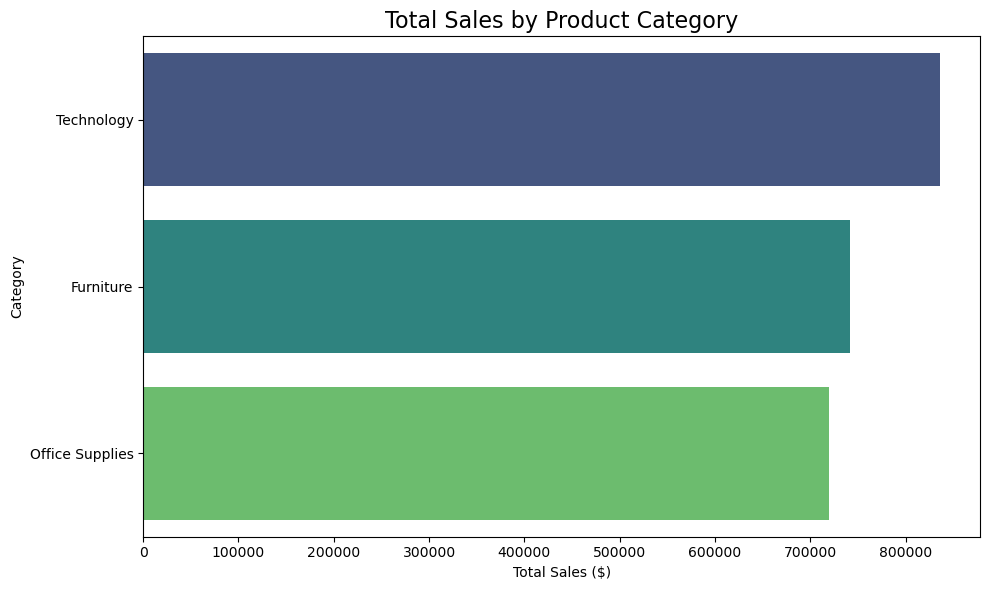

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index,
    hue=category_sales.index,
    palette="viridis",
    legend=False
)

plt.title("Total Sales by Product Category", fontsize=16)
plt.xlabel("Total Sales ($)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

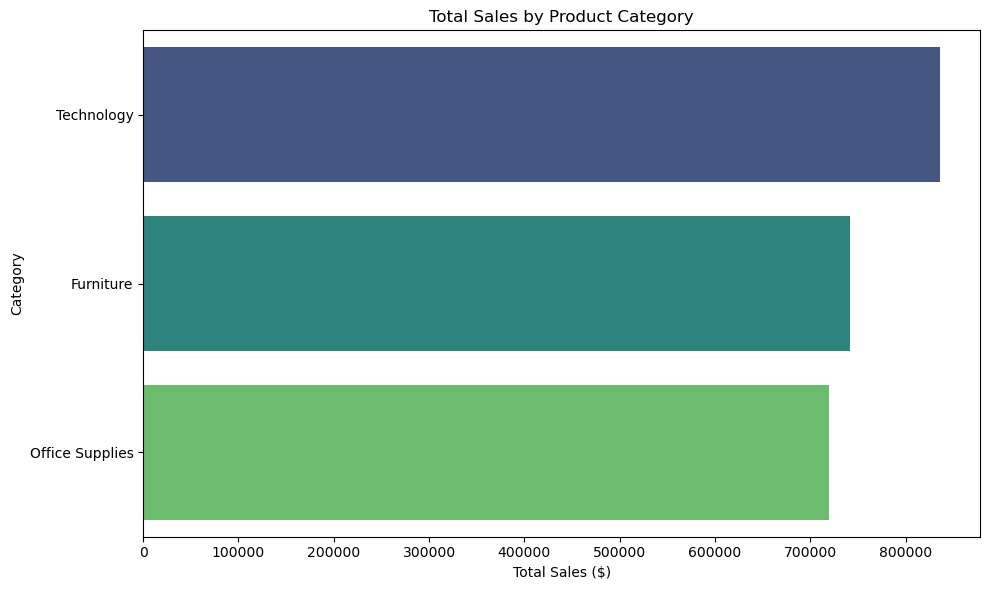

In [23]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index,
    hue=category_sales.index,
    palette="viridis",
    legend=False
)

plt.title("Total Sales by Product Category")
plt.xlabel("Total Sales ($)")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    "images/total_sales_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
category_sales.to_frame(name="Total Sales").style.format("${:,.2f}")

,Total Sales
category,
Technology,"$836,154.03"
Furniture,"$741,999.80"
Office Supplies,"$719,047.03"


In [20]:
category_profit = (
    df.groupby("category")["profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: profit, dtype: float64

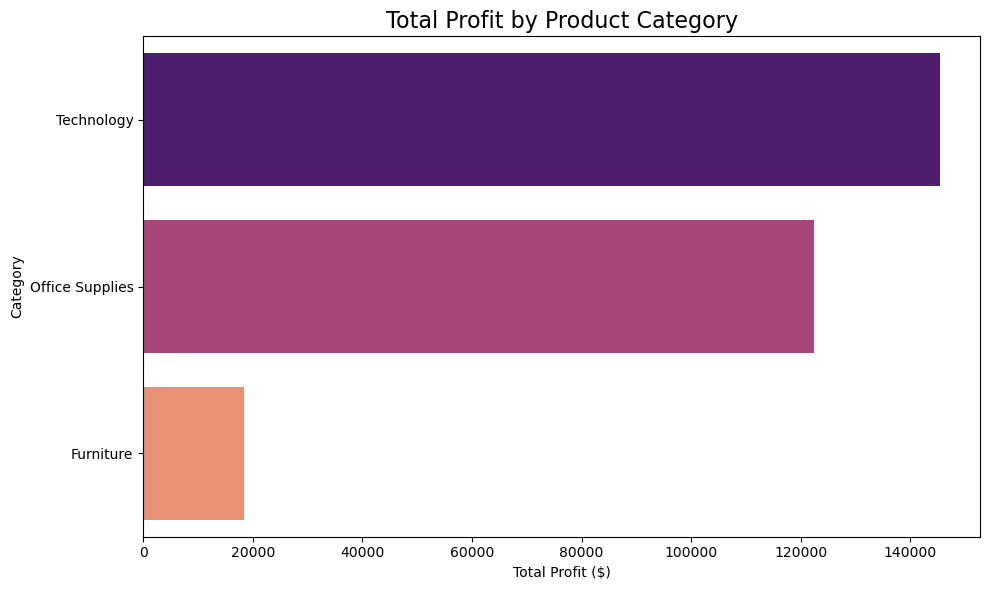

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=category_profit.values,
    y=category_profit.index,
    hue=category_profit.index,
    palette="magma",
    legend=False
)

plt.title("Total Profit by Product Category", fontsize=16)
plt.xlabel("Total Profit ($)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

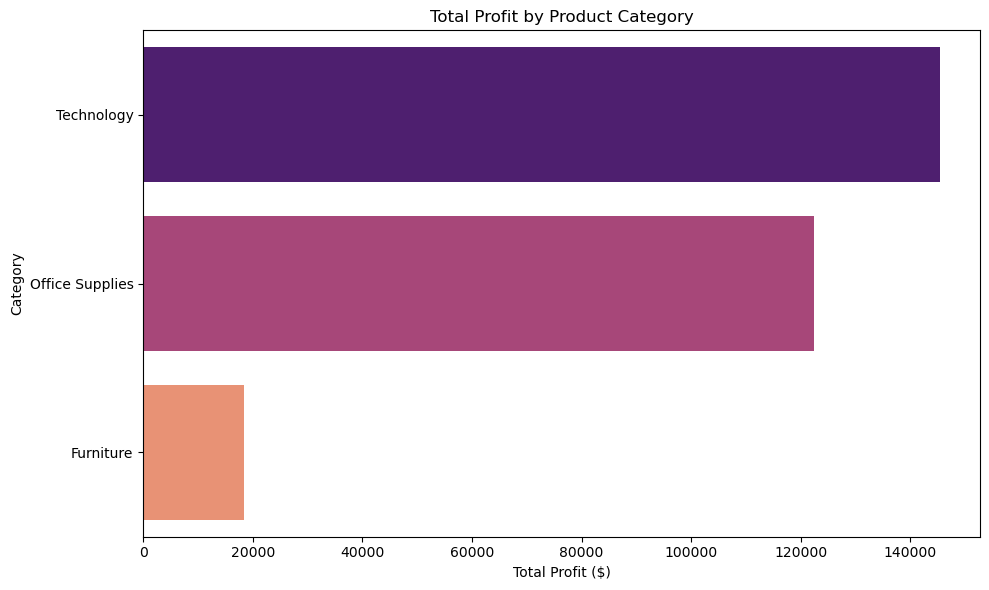

In [24]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_profit.values,
    y=category_profit.index,
    hue=category_profit.index,
    palette="magma",
    legend=False
)

plt.title("Total Profit by Product Category")
plt.xlabel("Total Profit ($)")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    "images/total_profit_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
category_profit.to_frame(name="Total Profit").style.format("${:,.2f}")

,Total Profit
category,
Technology,"$145,454.95"
Office Supplies,"$122,490.80"
Furniture,"$18,451.27"


In [25]:
region_sales = (
    df.groupby("region")["sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales

region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64

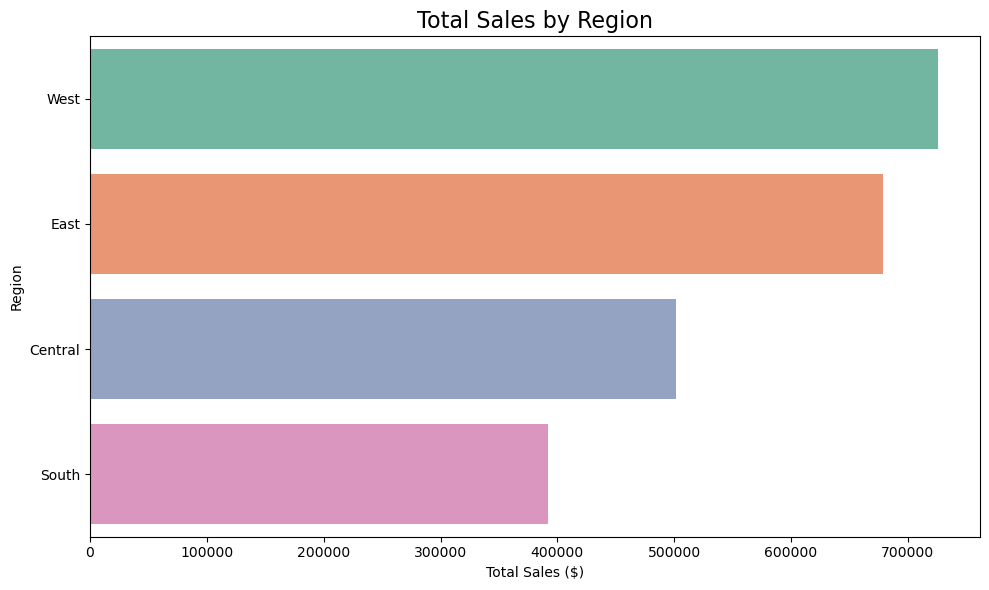

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=region_sales.values,
    y=region_sales.index,
    hue=region_sales.index,
    palette="Set2",
    legend=False
)

plt.title("Total Sales by Region", fontsize=16)
plt.xlabel("Total Sales ($)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

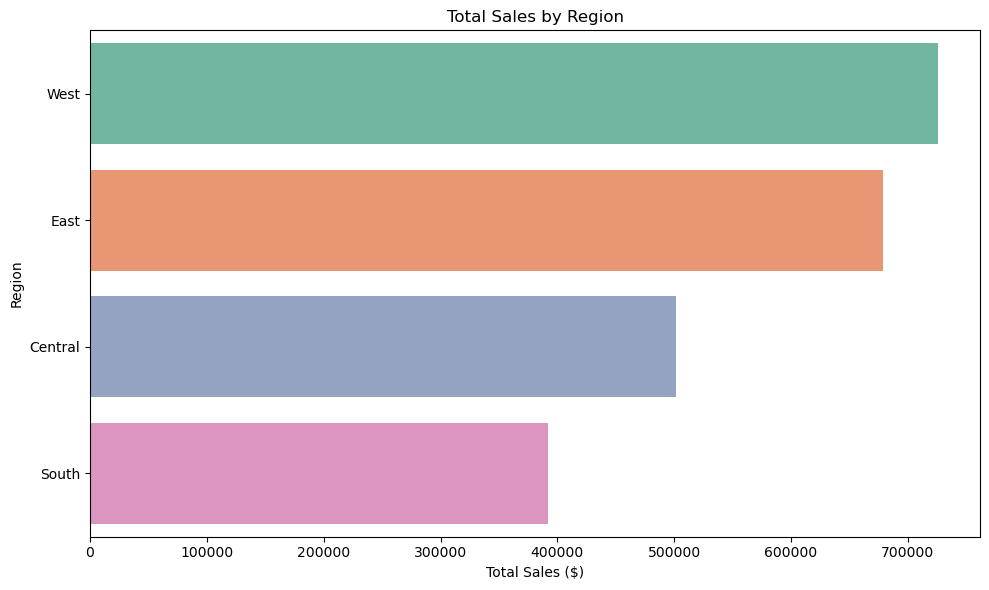

In [27]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(10,6))

sns.barplot(
    x=region_sales.values,
    y=region_sales.index,
    hue=region_sales.index,
    palette="Set2",
    legend=False
)

plt.title("Total Sales by Region")
plt.xlabel("Total Sales ($)")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig(
    "images/total_sales_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
region_sales.to_frame(name="Total Sales").style.format("${:,.2f}")

,Total Sales
region,
West,"$725,457.82"
East,"$678,781.24"
Central,"$501,239.89"
South,"$391,721.91"


In [29]:
state_sales = (
    df.groupby("state")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

state_sales

state
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: sales, dtype: float64

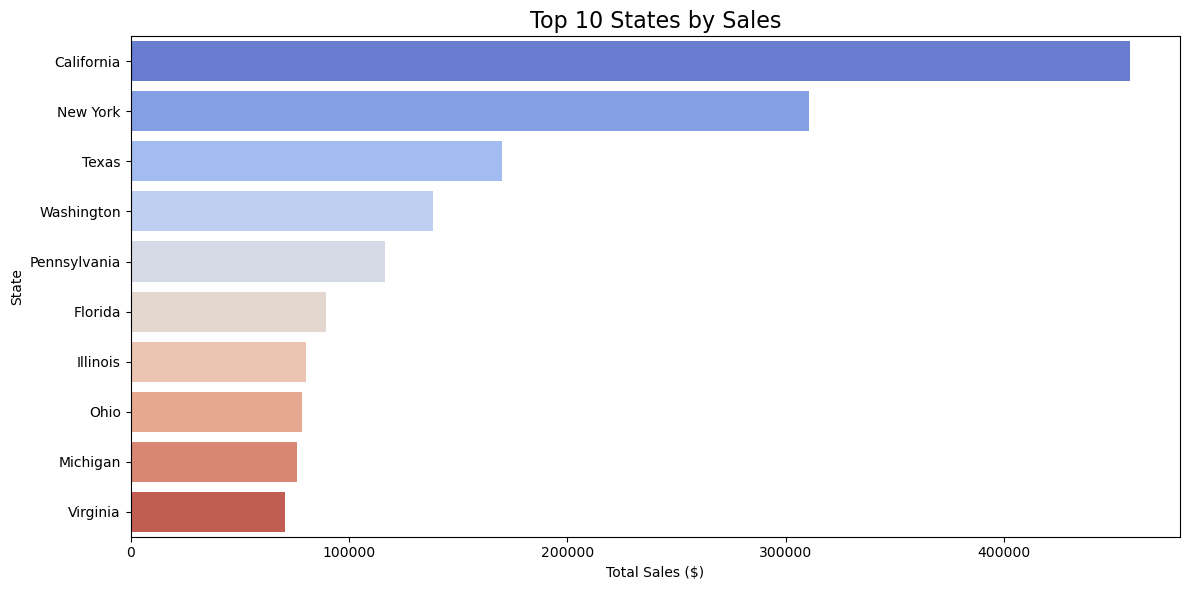

In [30]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=state_sales.values,
    y=state_sales.index,
    hue=state_sales.index,
    palette="coolwarm",
    legend=False
)

plt.title("Top 10 States by Sales", fontsize=16)
plt.xlabel("Total Sales ($)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

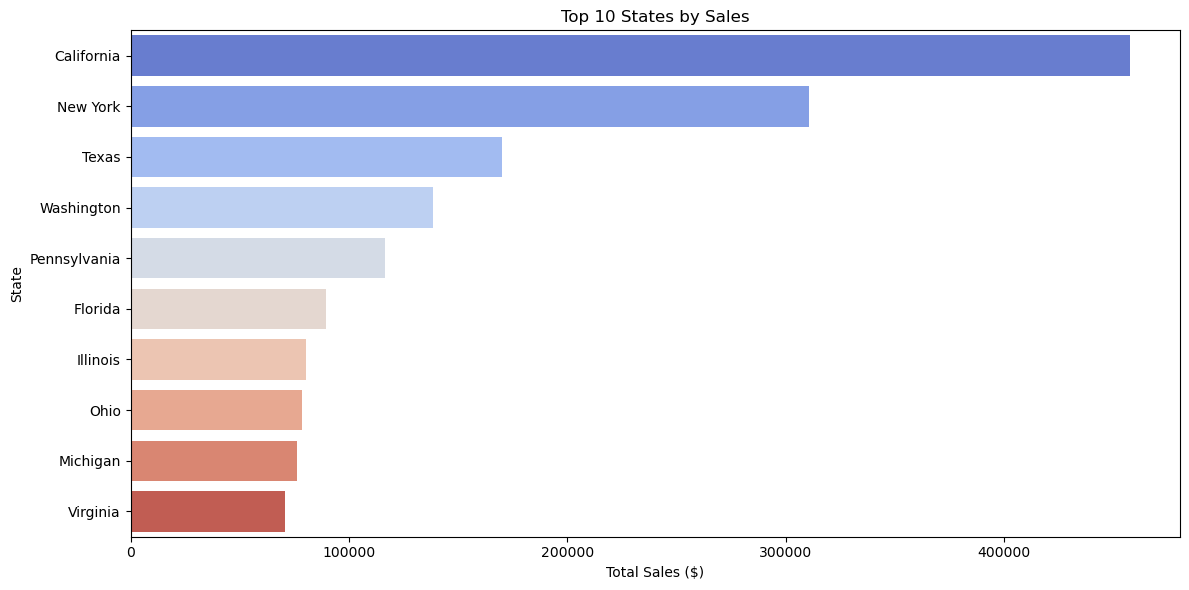

In [31]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_sales.values,
    y=state_sales.index,
    hue=state_sales.index,
    palette="coolwarm",
    legend=False
)

plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "images/top_10_states_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
state_sales.to_frame(name="Total Sales").style.format("${:,.2f}")

,Total Sales
state,
California,"$457,687.63"
New York,"$310,876.27"
Texas,"$170,188.05"
Washington,"$138,641.27"
Pennsylvania,"$116,511.91"
Florida,"$89,473.71"
Illinois,"$80,166.10"
Ohio,"$78,258.14"
Michigan,"$76,269.61"


In [33]:
segment_sales = (
    df.groupby("segment")["sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: sales, dtype: float64

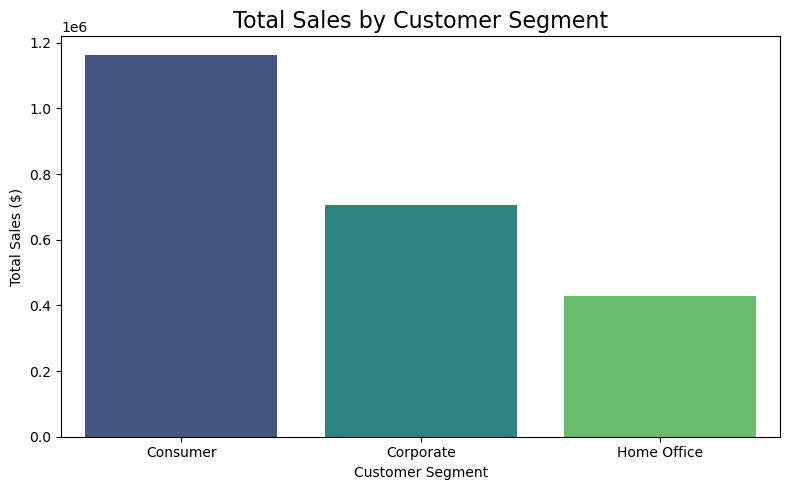

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values,
    hue=segment_sales.index,
    palette="viridis",
    legend=False
)

plt.title("Total Sales by Customer Segment", fontsize=16)
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales ($)")

plt.tight_layout()
plt.show()

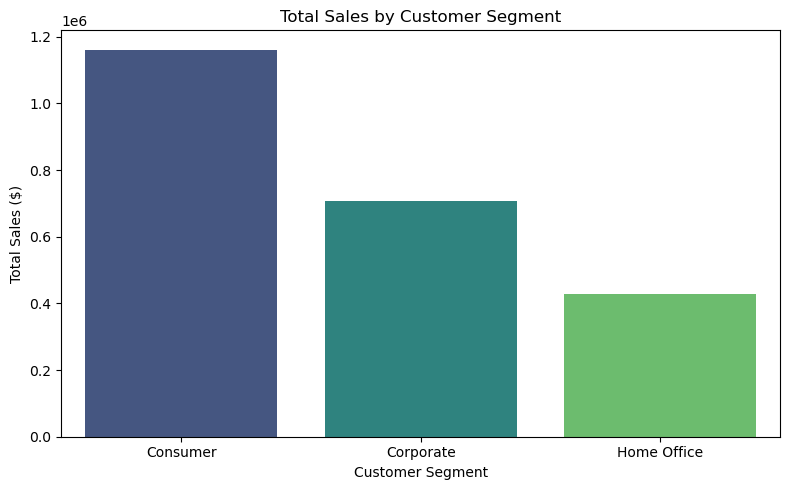

In [35]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values,
    hue=segment_sales.index,
    palette="viridis",
    legend=False
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales ($)")

plt.tight_layout()

plt.savefig(
    "images/sales_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
segment_sales.to_frame(name="Total Sales").style.format("${:,.2f}")

,Total Sales
segment,
Consumer,"$1,161,401.34"
Corporate,"$706,146.37"
Home Office,"$429,653.15"


In [37]:
top_products = (
    df.groupby("product_name")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64

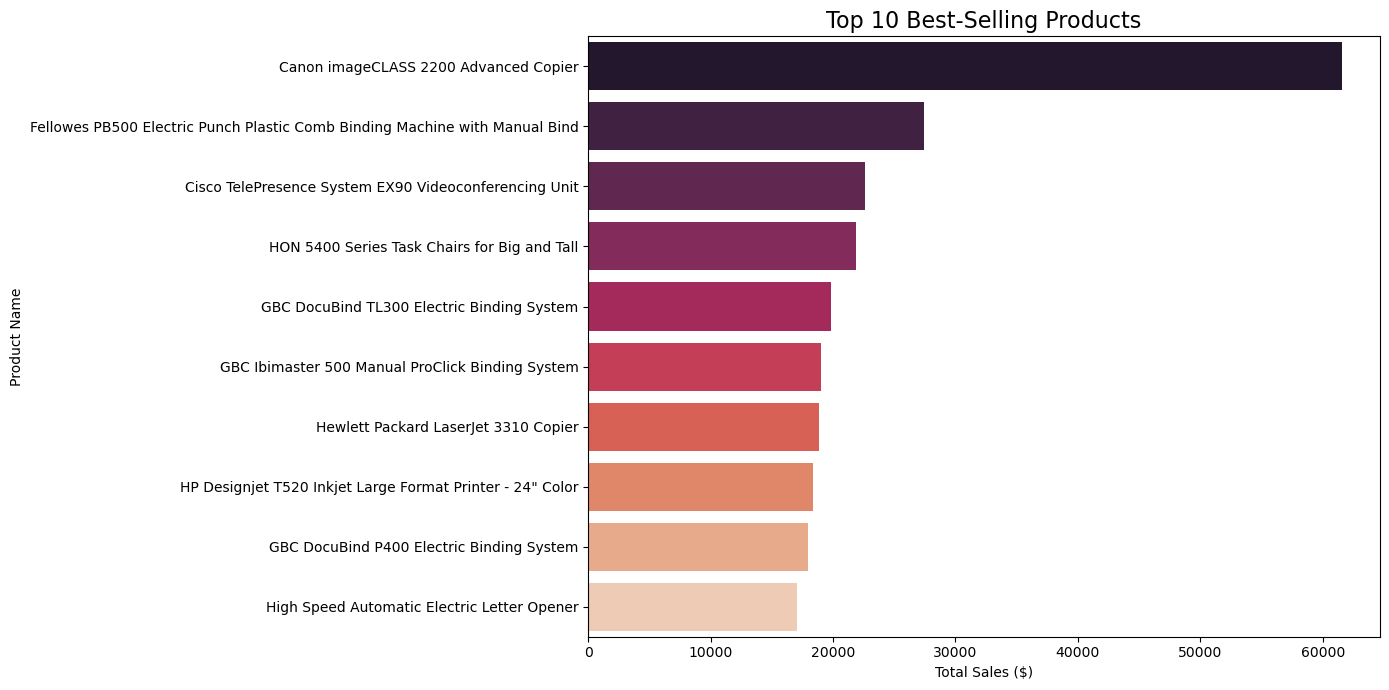

In [38]:
plt.figure(figsize=(14,7))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette="rocket",
    legend=False
)

plt.title("Top 10 Best-Selling Products", fontsize=16)
plt.xlabel("Total Sales ($)")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

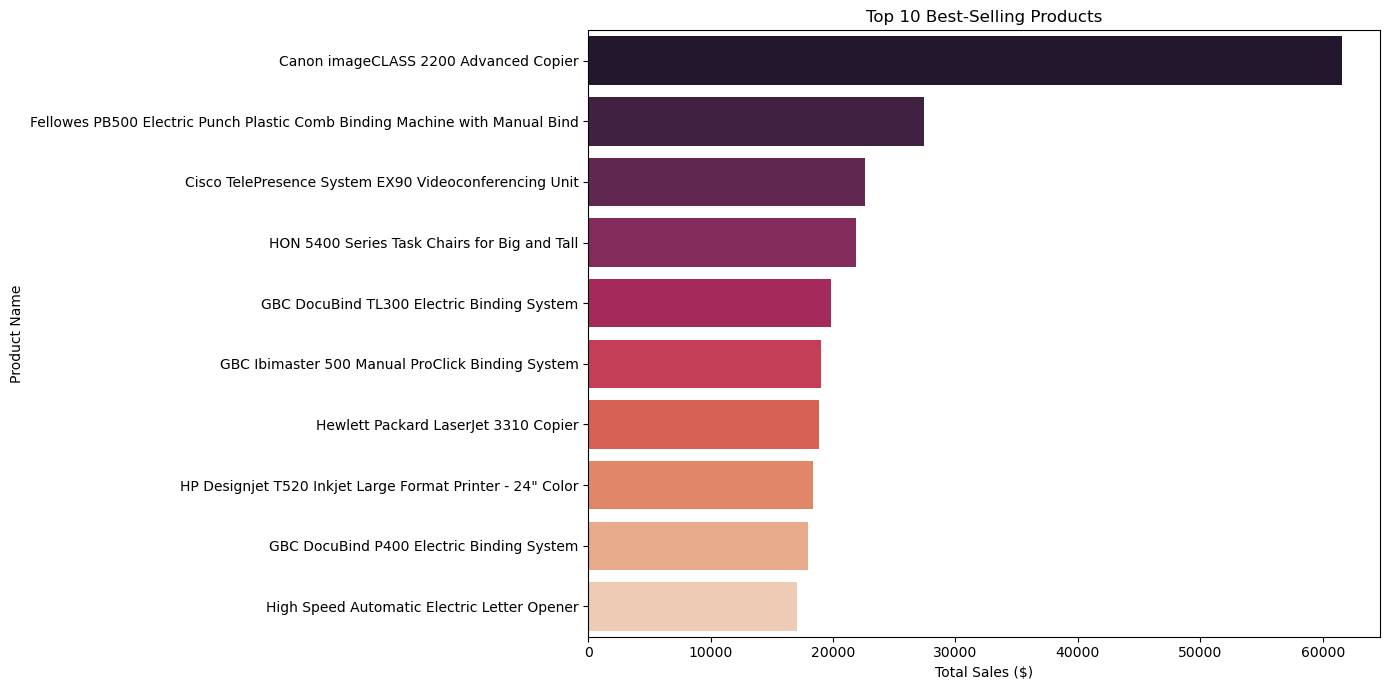

In [39]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(14,7))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette="rocket",
    legend=False
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Sales ($)")
plt.ylabel("Product Name")

plt.tight_layout()

plt.savefig(
    "images/top_10_best_selling_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
top_products.to_frame(name="Total Sales").style.format("${:,.2f}")

,Total Sales
product_name,
Canon imageCLASS 2200 Advanced Copier,"$61,599.82"
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,"$27,453.38"
Cisco TelePresence System EX90 Videoconferencing Unit,"$22,638.48"
HON 5400 Series Task Chairs for Big and Tall,"$21,870.58"
GBC DocuBind TL300 Electric Binding System,"$19,823.48"
GBC Ibimaster 500 Manual ProClick Binding System,"$19,024.50"
Hewlett Packard LaserJet 3310 Copier,"$18,839.69"
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color","$18,374.90"
GBC DocuBind P400 Electric Binding System,"$17,965.07"


In [41]:
monthly_sales = (
    df.groupby("order_month")["sales"]
      .sum()
      .reindex([
          "January", "February", "March", "April",
          "May", "June", "July", "August",
          "September", "October", "November", "December"
      ])
)

monthly_sales

order_month
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: sales, dtype: float64

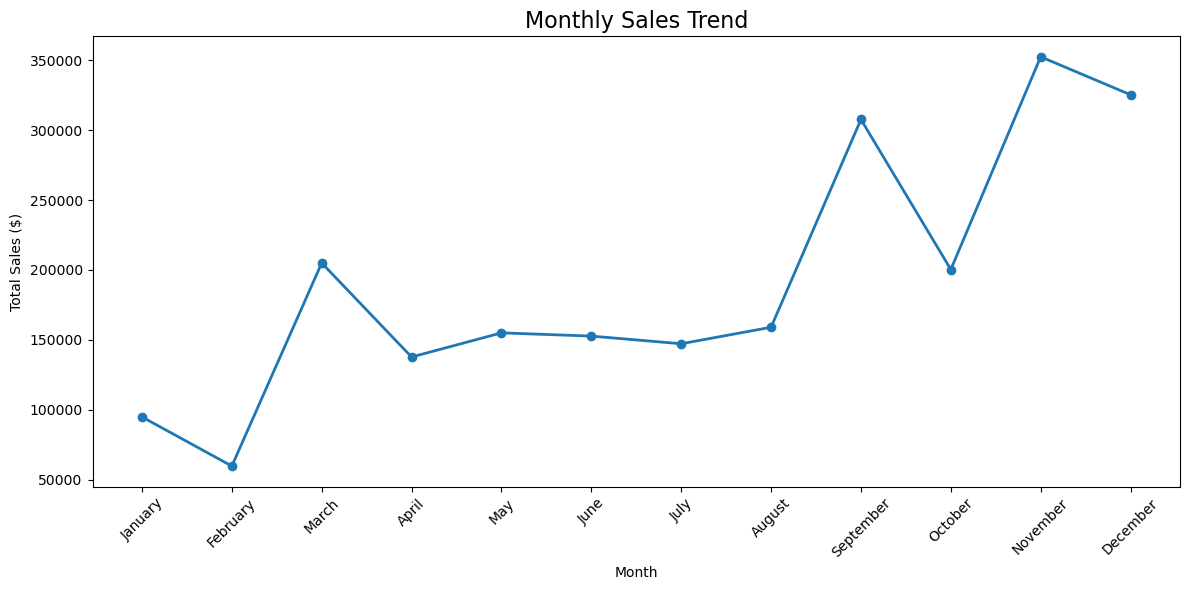

In [42]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

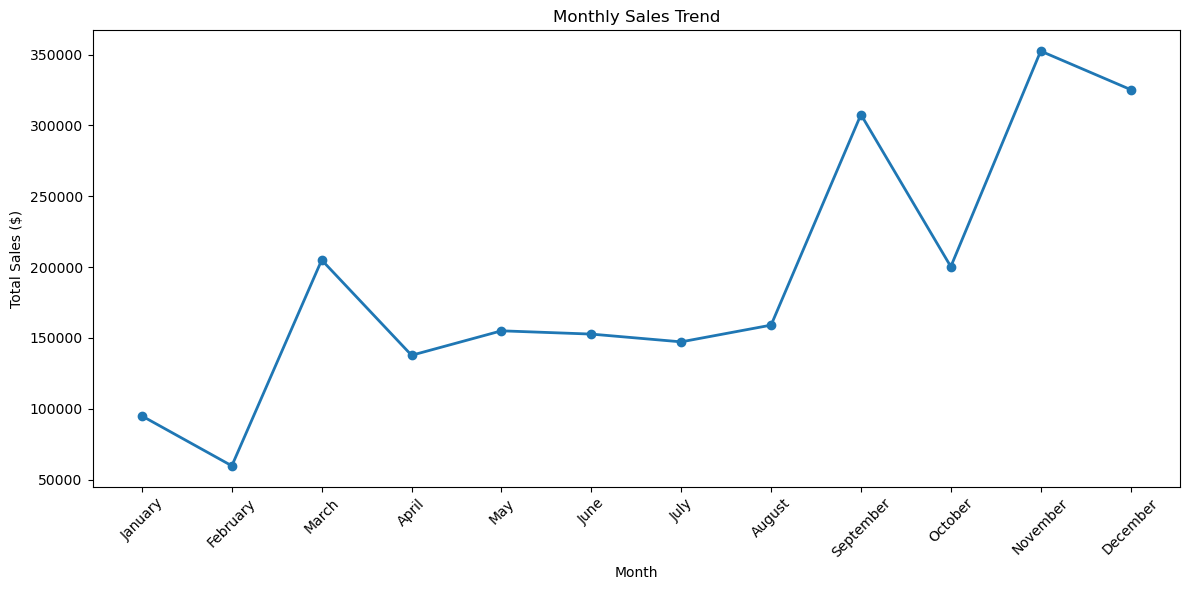

In [43]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "images/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
monthly_sales.to_frame(name="Total Sales").style.format("${:,.2f}")

,Total Sales
order_month,
January,"$94,924.84"
February,"$59,751.25"
March,"$205,005.49"
April,"$137,762.13"
May,"$155,028.81"
June,"$152,718.68"
July,"$147,238.10"
August,"$159,044.06"
September,"$307,649.95"


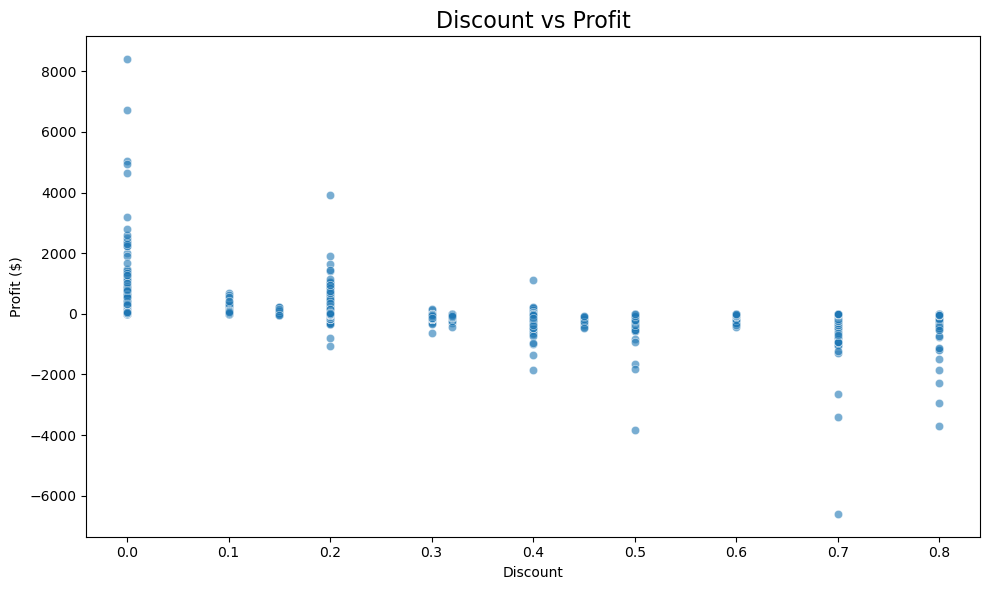

In [45]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="discount",
    y="profit",
    alpha=0.6
)

plt.title("Discount vs Profit", fontsize=16)
plt.xlabel("Discount")
plt.ylabel("Profit ($)")

plt.tight_layout()
plt.show()

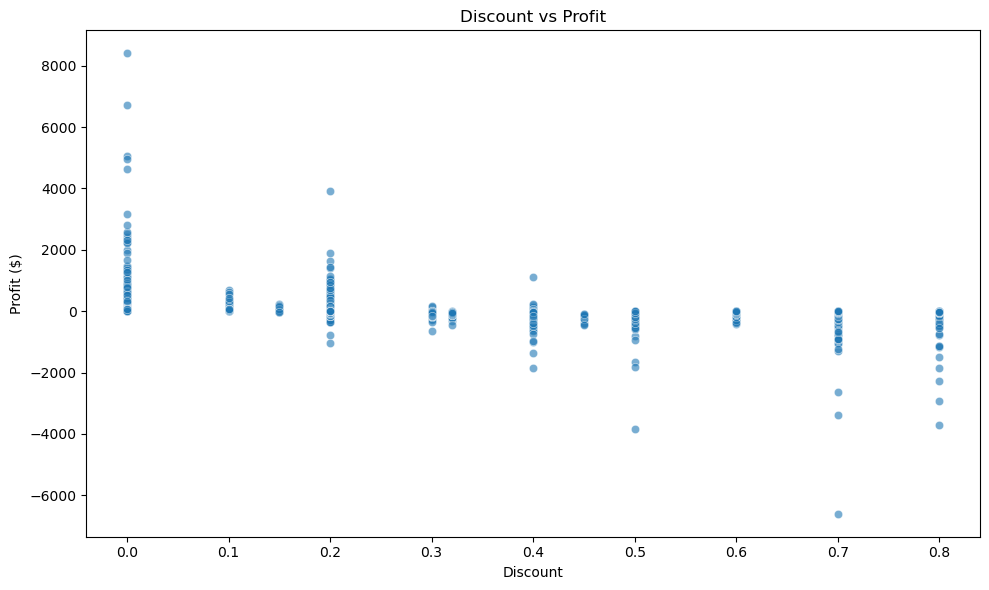

In [46]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="discount",
    y="profit",
    alpha=0.6
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")

plt.tight_layout()

plt.savefig(
    "images/discount_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
correlation = df["discount"].corr(df["profit"])

print(f"Correlation between Discount and Profit: {correlation:.2f}")

Correlation between Discount and Profit: -0.22


In [48]:
df[["discount", "profit"]].describe().style.format("{:.2f}")

,discount,profit
count,9994.00,9994.00
mean,0.16,28.66
std,0.21,234.26
min,0.00,-6599.98
25%,0.00,1.73
50%,0.20,8.67
75%,0.20,29.36
max,0.80,8399.98


In [49]:
shipping_mode = (
    df["ship_mode"]
      .value_counts()
)

shipping_mode

ship_mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

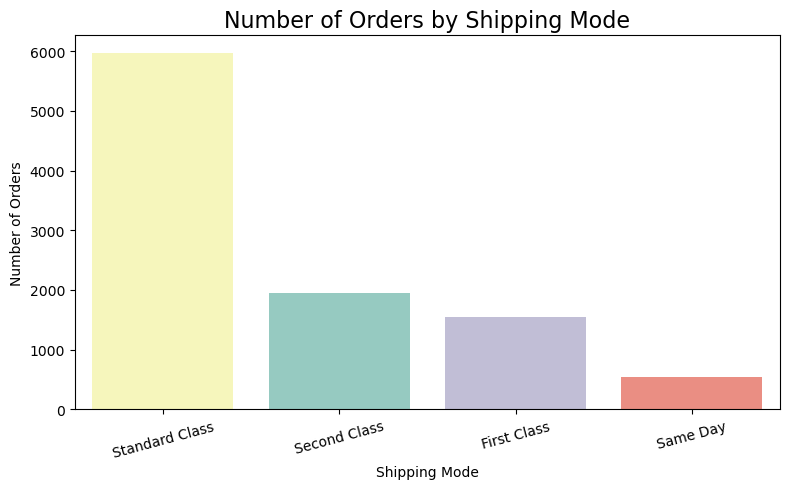

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="ship_mode",
    hue="ship_mode",
    palette="Set3",
    legend=False,
    order=df["ship_mode"].value_counts().index
)

plt.title("Number of Orders by Shipping Mode", fontsize=16)
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

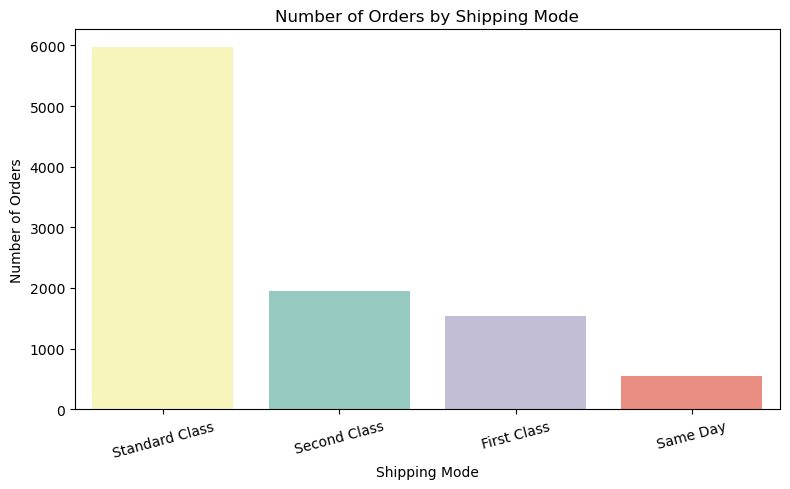

In [51]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="ship_mode",
    hue="ship_mode",
    palette="Set3",
    legend=False,
    order=df["ship_mode"].value_counts().index
)

plt.title("Number of Orders by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "images/orders_by_shipping_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
shipping_mode.to_frame(name="Number of Orders")

,Number of Orders
ship_mode,
Standard Class,5968
Second Class,1945
First Class,1538
Same Day,543


In [53]:
correlation_data = df[["sales", "profit", "discount", "quantity"]]

In [54]:
correlation_matrix = correlation_data.corr()

correlation_matrix

,sales,profit,discount,quantity
sales,1.000000,0.479064,-0.028190,0.200795
profit,0.479064,1.000000,-0.219487,0.066253
discount,-0.028190,-0.219487,1.000000,0.008623
quantity,0.200795,0.066253,0.008623,1.000000


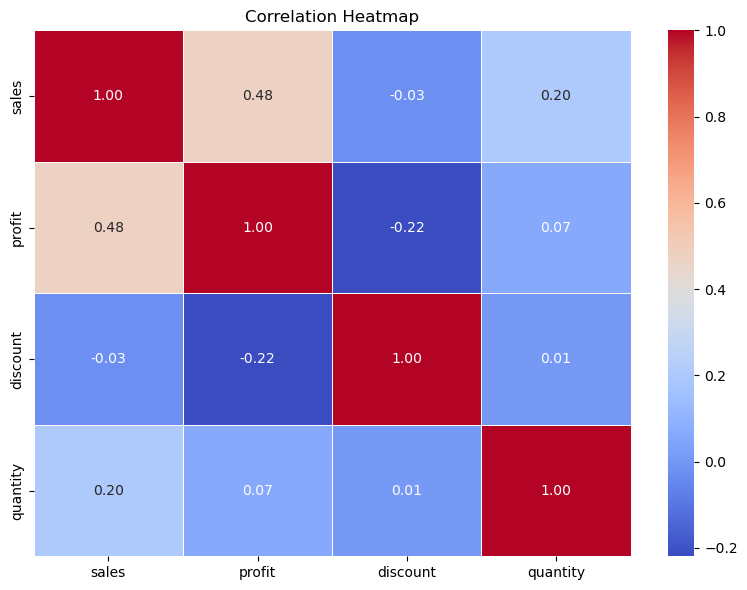

In [55]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

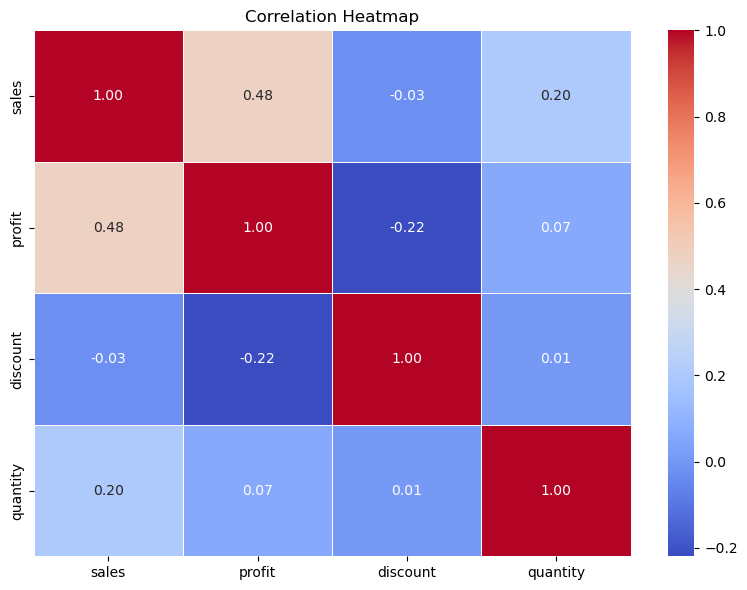

In [56]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
correlation_matrix.style.background_gradient(cmap="coolwarm").format("{:.2f}")

,sales,profit,discount,quantity
sales,1.00,0.48,-0.03,0.20
profit,0.48,1.00,-0.22,0.07
discount,-0.03,-0.22,1.00,0.01
quantity,0.20,0.07,0.01,1.00
